<a href="https://colab.research.google.com/github/Milariano/Atlas-de-Desarrollo-Humano-Cantonal/blob/main/Laboratorio1_CamilaRia%C3%B1o_C36535.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### GF-0624 Cartografía Multivariada y Geovisualización
#### Laboratorio 1 — Camila Riaño Rodríguez C36535
# **Zona de estudio: Airbnb Dublin, Leinster, Ireland**

---
**Semana 3 - I Ciclo 2026 - UCR Escuela de Geografía**
---
## Contenido del Laboratorio 1

| Bloque                    | Desarrollo
|---------------------------|--------------------------
| 0 - EDA  Reconocimiento| Cargar datos, clasificar variables, diagnóstico de nulos y duplicados
| 1 - EDA Precio| Subconjunto analítico, estadísticas descriptivas, diagnóstico de sesgo
| 2 - EDA Transformaciones|Histograma original vs. log₁₀, capping al P99
| 3 - EDA Bivariado| Análisis por tipo de alojamiento, por barrio, correlación
| 4 - ESDA Espacial| Mapa de puntos, densidad, spatial join, coroplético
| 5 - RETO  Gráfico nuevo| Un gráfico o análisis no visto en el laboratorio

---

**Dataset de entrada:** `listings.csv` —  6141 alojamientos · 18 variables

**Dataset de salida:** `Dubling_listings_clean.csv`



---

### Pregunta problema:

> **¿Tiene el precio de los alojamientos Airbnb en Dublin, Leinster, Ireland un patrón territorial que podamos cartografiar de forma rigurosa?**

## EDA vs. ESDA

| | EDA | ESDA |
|---|---|---|
| **¿Qué analiza?** | La distribución estadística de los datos | La distribución estadística + su patrón en el espacio |
| **Pregunta típica** | ¿Cómo se distribuye el precio? | ¿Los precios altos se concentran en ciertos barrios? |

> El EDA es condición necesaria para el ESDA. No tiene sentido analizar la distribución espacial de una variable que no entendemos estadísticamente.

---
#Bloque 0 - EDA  Reconocimiento

### Cargar datos, clasificar variables, diagnóstico de nulos y duplicados



In [1]:
# pandas  → trabajar con tablas de datos
# numpy   → operaciones matemáticas (logaritmos, etc.)
# matplotlib → hacer gráficos
# seaborn → mejorar el aspecto de los gráficos

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual de los gráficos
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', context='notebook')

print('✓ Librerías cargadas correctamente')

✓ Librerías cargadas correctamente


  ## 0.1 Cargamos el dataset de Dublín
  

In [2]:
df = pd.read_csv('listings.csv')

print('Filas:   ', df.shape[0])
print('Columnas:', df.shape[1])

Filas:    6945
Columnas: 18



## 0.2 Primera vista del dataset


In [3]:
#Con el comando df.head le pedimos que muestre las primeras 5 filas del dataframe como una tabla
df.head(5)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,44077,cosy comfortable Irish cottage twin,193005,Teresa,NaN,Dn Laoghaire-Rathdown,53.29178,-6.25792,Private room,86.0,3,394,2025-09-13,2.23,2,9,37,NaN
1,85156,Cosy Comfortable Irish Cottage 1 Double Bed,193005,Teresa,NaN,Dn Laoghaire-Rathdown,53.29209,-6.25624,Private room,NaN,3,357,2025-09-14,2.05,2,7,41,NaN
2,159889,Friendly Single Room,766611,Marie,NaN,Dublin City,53.39027,-6.23547,Private room,48.0,2,464,2025-09-14,2.82,3,312,20,NaN
3,162809,5.5 miles south of Dublin City :^),777681,Robbie,NaN,Dn Laoghaire-Rathdown,53.28326,-6.19188,Private room,101.0,2,397,2025-09-11,3.17,2,7,8,NaN
4,237465,Cozy 1 bed apt 10 mins to airport. total privacy,1245198,Amanda,NaN,Dublin City,53.39558,-6.17524,Entire home/apt,NaN,1,599,2025-09-09,3.58,3,134,60,NaN


## 0.3 Tipos de dato en cada columna y valores nulos que contiene el DF



In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6945 entries, 0 to 6944
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              6945 non-null   int64  
 1   name                            6945 non-null   object 
 2   host_id                         6945 non-null   int64  
 3   host_name                       6944 non-null   object 
 4   neighbourhood_group             0 non-null      float64
 5   neighbourhood                   6945 non-null   object 
 6   latitude                        6945 non-null   float64
 7   longitude                       6945 non-null   float64
 8   room_type                       6945 non-null   object 
 9   price                           5244 non-null   float64
 10  minimum_nights                  6945 non-null   int64  
 11  number_of_reviews               6945 non-null   int64  
 12  last_review                     59

In [5]:
# Observar todos los nombres de las columnas
print('Columnas del dataset:')
print(df.columns.tolist())

Columnas del dataset:
['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm', 'license']


## 0.4 Clasificación de las columnas segun el tipo de uso
#### Cada columna va a ser agrupada según su función analítica

In [6]:
id_cols      = ['id', 'host_id']
text_cols    = ['name', 'host_name', 'license']
cat_cols     = ['neighbourhood_group', 'neighbourhood', 'room_type']
num_cols     = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month',
                'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm']
date_cols    = ['last_review']
spatial_cols = ['latitude', 'longitude']

print('Identificadores:', id_cols)
print('Texto libre:    ', text_cols)
print('Categóricas:    ', cat_cols)
print('Numéricas:      ', num_cols)
print('Temporal:       ', date_cols)
print('Espaciales:     ', spatial_cols)

Identificadores: ['id', 'host_id']
Texto libre:     ['name', 'host_name', 'license']
Categóricas:     ['neighbourhood_group', 'neighbourhood', 'room_type']
Numéricas:       ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm']
Temporal:        ['last_review']
Espaciales:      ['latitude', 'longitude']


---
## Naturaleza de las variables

### Tres dimensiones para clasificar cualquier variable

**Dimensión 1 — ¿Normalización necesaria?**
- **Absoluta:** cantidad bruta (depende del tamaño de la unidad). Ej: número de reseñas totales.
- **Relativa:** normalizada por unidad de referencia. Ej: reseñas por mes (`reviews_per_month`).

**Dimensión 2 — ¿La suma entre unidades tiene sentido geográfico?**
- **Extensiva:** aditiva — sumar tiene sentido. Ej: número de alojamientos por barrio.
- **Intensiva:** no aditiva — se promedia. Ej: precio por noche (`price`).

**Dimensión 3 — Escala de medición**
- **Nominal:** categorías sin orden (`room_type`, `neighbourhood_group`).
- **Razón:** cero absoluto real (`price`, `number_of_reviews`).

---


## 0.5 Diagnóstico de nulos y duplicados
## 0.5.1 Valores nulos
#### Aquellas celdas del DF que se encuentran vacias o con datos faltantes

In [7]:
# Paso 1: contar cuántos nulos hay en cada columna
conteo_nulos = df.isna().sum()

# Paso 2: ordenar de mayor a menor
conteo_nulos = conteo_nulos.sort_values(ascending=False)

# Paso 3: calcular el porcentaje de nulos
pct_nulos = (df.isna().mean() * 100).round(1)

# Paso 4: mostrar solo las columnas que TIENEN nulos
print('Columnas con valores nulos:')
print()

for columna in conteo_nulos.index:
    n = conteo_nulos[columna]
    if n > 0:
        pct = pct_nulos[columna]
        print(f'  {columna}: {n} nulos ({pct}%)')

Columnas con valores nulos:

  license: 6945 nulos (100.0%)
  neighbourhood_group: 6945 nulos (100.0%)
  price: 1701 nulos (24.5%)
  reviews_per_month: 1042 nulos (15.0%)
  last_review: 1042 nulos (15.0%)
  host_name: 1 nulos (0.0%)


## 0.5.2 Valores Duplicados
####  Identifica las filas en donde se encuetran registros de alojamientos dobles


In [8]:
 #Contar filas completamente duplicadas
filas_duplicadas = df.duplicated().sum()

# Contar IDs duplicados (mismo alojamiento registrado dos veces)
ids_duplicados = df['id'].duplicated().sum()

print('Diagnóstico de duplicados:')
print()

if filas_duplicadas == 0:
    print('No hay filas completamente duplicadas.')
else:
    print('Hay', filas_duplicadas, 'filas duplicadas.')

if ids_duplicados == 0:
    print('No hay IDs duplicados.')
else:
    print('Hay', ids_duplicados, 'IDs duplicados.')

Diagnóstico de duplicados:

No hay filas completamente duplicadas.
No hay IDs duplicados.


## 0.5.3 Correción del tipo de fecha
#### Pandas lee las fechas como texto. Necesitamos convertirlas al tipo correcto para poder trabajar con ellas.

In [9]:
# Convertir la columna de fechas de texto a formato datetime
# errors='coerce' → si hay algún texto que no es fecha, lo convierte a vacío (NaT)
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')

print('Tipo de dato de last_review:', df['last_review'].dtype)
print('Fechas válidas:             ', df['last_review'].notna().sum())
print('Fechas vacías (NaT):        ', df['last_review'].isna().sum())

Tipo de dato de last_review: datetime64[ns]
Fechas válidas:              5903
Fechas vacías (NaT):         1042


---
# Bloque 1 —  EDA Precio

### Subconjunto analítico, estadísticas descriptivas, diagnóstico de sesgo


##  1.1  Separar los alojamientos que si tienen precio para poder utilizar la variable *precio*

In [10]:
# Generamos una copia del Dataset para generar los análisis
# Guardamos el dataset original intacto
df_original = df.copy()

# Creamos la condición: True donde price tiene valor, False donde está vacío
tiene_precio = df['price'].notna()

# Filtramos: nos quedamos solo con las filas donde tiene_precio es True
df_work = df[tiene_precio].copy()

# Mostramos el resultado
print('Dataset original: ', len(df_original), 'filas')
print('Con precio válido:', len(df_work), 'filas')

excluidos = len(df_original) - len(df_work)
print('Excluidos:        ', excluidos, 'filas (sin precio)')

Dataset original:  6945 filas
Con precio válido: 5244 filas
Excluidos:         1701 filas (sin precio)


In [11]:
# Verificación: ¿quedaron nulos en price?
nulos_restantes = df_work['price'].isna().sum()

if nulos_restantes == 0:
    print(' Verificación correcta: no hay valores nulos en price.')
else:
    print('Aún hay', nulos_restantes, 'valores nulos en price.')

 Verificación correcta: no hay valores nulos en price.


## 1.2 Datos originales de los precios del airbnb en Dublin



### Media vs. mediana

- **Media:** sensible a valores extremos — se *jala* hacia la cola.
- **Mediana:** resistente a outliers — representa mejor el caso típico.

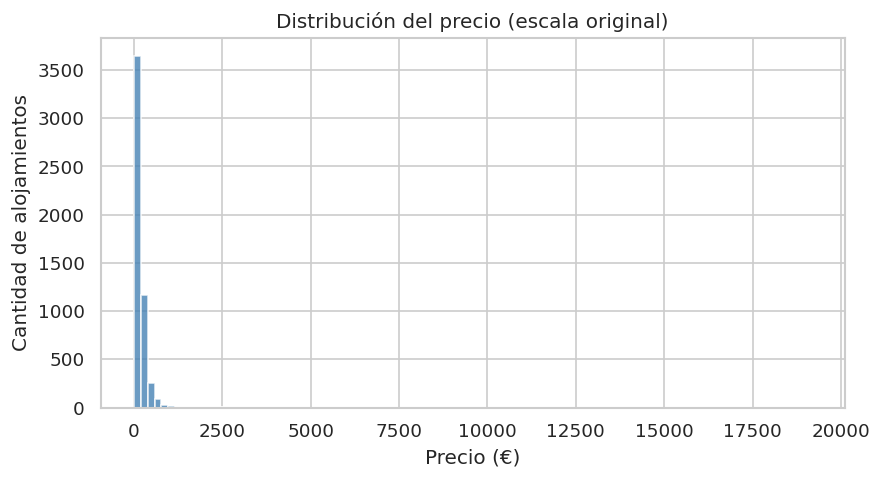

Precio mínimo: 16.0
Precio máximo: 19140.0


In [12]:
# Histograma del precio en escala original
plt.figure(figsize=(8, 4))
plt.hist(df_work['price'], bins=100, color='steelblue', alpha=0.8)
plt.title('Distribución del precio (escala original)')
plt.xlabel('Precio (€)')
plt.ylabel('Cantidad de alojamientos')
plt.show()

print('Precio mínimo:', df_work['price'].min())
print('Precio máximo:', df_work['price'].max())

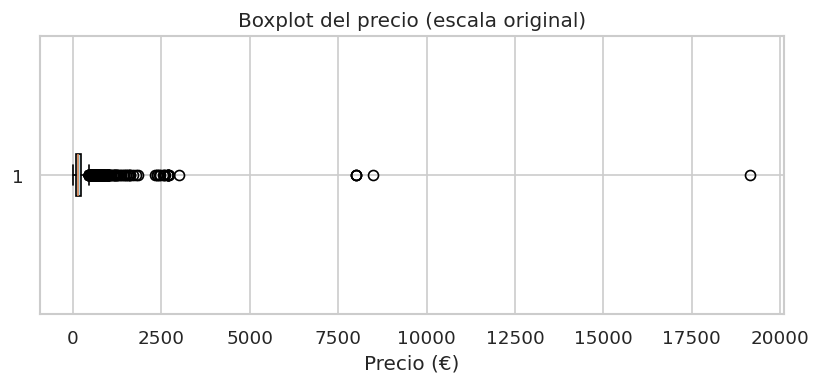

In [13]:
# Boxplot del precio en escala original
plt.figure(figsize=(8, 3))
plt.boxplot(df_work['price'], vert=False, patch_artist=True,
            boxprops=dict(facecolor='lightblue'))
plt.title('Boxplot del precio (escala original)')
plt.xlabel('Precio (€)')
plt.show()

---

En base a los resultados de la escala original:

¿Podemos realmente interpretar cómo se distribuyen los precios?
> No de manera clara. En la escala original, la distribución presenta una fuerte asimetría y una "cola larga" hacia la derecha, lo que provoca que el comportamiento del mercado típico aparezca comprimido e ilegible. Casi todos los datos se amontonan en la clase más baja, impidiendo ver las variaciones reales entre la mayoría de los alojamientos.

¿Qué efecto tienen los valores extremadamente altos en la visualización?
>  Los valores extremos distorsionan la escala visual de los gráficos. Al existir un precio máximo de €19,140.00, que es 19 veces superior al percentil 99 (€1,000.00), el eje horizontal se expande tanto que la caja del boxplot y las barras principales del histograma se vuelven demasiado pequeñas para ser analizadas.

¿La media sería una buena medida representativa en este caso?
> No. El documento explica que la media es sensible a valores extremos y se ve arrastrada hacia la cola de la distribución, situándose en €204.50. El diagnóstico confirma que, en este caso de sesgo positivo, la media sobreestima el precio típico de un alojamiento, por lo que es mejor utilizar la mediana (€137.00) como medida representativa.

¿Estamos viendo la estructura real del mercado o el efecto de unos pocos valores extremos?
> Estamos viendo principalmente el efecto de unos pocos valores extremos. La visualización en escala original oculta la estructura real del mercado masivo debido a la dispersión extrema (la desviación estándar es de €400.98, mayor que la propia media). Solo mediante transformaciones como el logaritmo o el "capping" al percentil 99 se logra visualizar la estructura real y legible del mercado típico



## 1.3 Calculo de las estadísticas


In [14]:
# Calcular cada estadística y guardarla en su propia variable
media   = df_work['price'].mean()
mediana = df_work['price'].median()
std     = df_work['price'].std()
skew    = df_work['price'].skew()
Q1      = df_work['price'].quantile(0.25)
Q3      = df_work['price'].quantile(0.75)
IQR     = Q3 - Q1

print('=== Estadísticas del precio ===')
print(f'Media:              €{media:.2f}')
print(f'Mediana:            €{mediana:.2f}')
print(f'Desv. estándar:     €{std:.2f}')
print(f'Skewness:           {skew:.2f}')
print(f'Q1 (P25):           €{Q1:.2f}')
print(f'Q3 (P75):           €{Q3:.2f}')
print(f'IQR (Q3 - Q1):      €{IQR:.2f}')

=== Estadísticas del precio ===
Media:              €204.50
Mediana:            €137.00
Desv. estándar:     €400.98
Skewness:           26.85
Q1 (P25):           €89.00
Q3 (P75):           €232.00
IQR (Q3 - Q1):      €143.00


In [15]:
# Diagnóstico automático basado en las estadísticas calculadas
diferencia = media - mediana
ratio = media / mediana

print('=== Diagnóstico ===')
print(f'Diferencia media − mediana: €{diferencia:.2f}')
print(f'Ratio media / mediana:      {ratio:.1f}x')
print()

if media > mediana * 1.1:
    print('La media es notablemente mayor que la mediana.')
    print('  Sesgo positivo confirmado.')
    print('  Implicación cartográfica: la media por barrio sobreestima el precio típico.')

if std > media:
    print()
    print('La desviación estándar es mayor que la media.')
    print('  La dispersión es extrema: usar IQR en lugar de SD.')

=== Diagnóstico ===
Diferencia media − mediana: €67.50
Ratio media / mediana:      1.5x

La media es notablemente mayor que la mediana.
  Sesgo positivo confirmado.
  Implicación cartográfica: la media por barrio sobreestima el precio típico.

La desviación estándar es mayor que la media.
  La dispersión es extrema: usar IQR en lugar de SD.


###  Regla de compatibilidad (Slocum - en lectura obligaotiria de la semana)

| Situación | Par correcto | Par INCORRECTO |
|-----------|-------------|----------------|
| Distribución **asimétrica** (este caso) | Mediana + IQR ✔ | Media + IQR ✗ |
| Distribución **simétrica** | Media + SD ✔ | Mediana + SD ✗ |

## 1.4 Transformación logarítmica

La transformación log₁₀ **comprime los valores altos y expande los bajos**, haciendo la distribución más simétrica y legible.

> No reemplaza los datos originales — creamos una columna nueva `price_log10`.

In [16]:
# Crear la columna price_log10
# clip(lower=1) → si hubiera precios de €0, evita que log(0) genere error
df_work['price_log10'] = np.log10(df_work['price'].clip(lower=1))

print('Nueva columna creada: price_log10')
print()
print(df_work['price_log10'].describe())

Nueva columna creada: price_log10

count    5244.000000
mean        2.170168
std         0.306439
min         1.204120
25%         1.949390
50%         2.136721
75%         2.365488
max         4.281942
Name: price_log10, dtype: float64


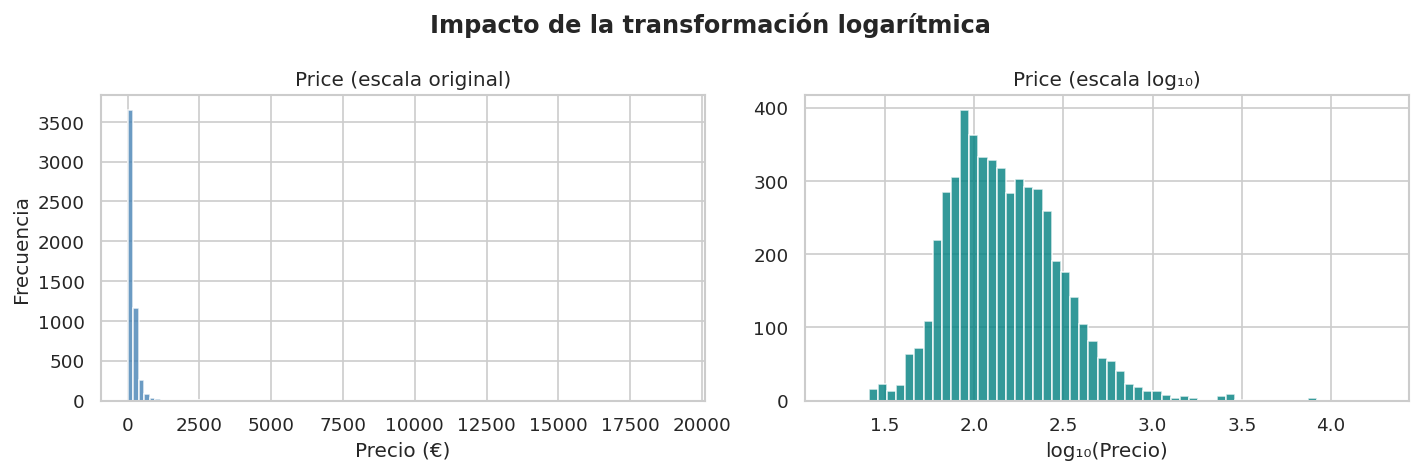

In [17]:
# Comparación visual: precio original vs. transformado
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_work['price'], bins=100, color='steelblue', alpha=0.8)
axes[0].set_title('Price (escala original)')
axes[0].set_xlabel('Precio (€)')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(df_work['price_log10'], bins=60, color='teal', alpha=0.8)
axes[1].set_title('Price (escala log₁₀)')
axes[1].set_xlabel('log₁₀(Precio)')

plt.suptitle('Impacto de la transformación logarítmica', fontweight='bold')
plt.tight_layout()
plt.show()


**Lectura del gráfico:**
- **Izquierda (original):** fuerte asimetría, cola larga, comportamiento típico comprimido.
- **Derecha (log₁₀):** distribución más simétrica, el mercado típico es legible.

> **Implicación cartográfica:** con intervalos iguales en la escala original, casi todos los barrios quedarán en la clase más baja. Con log₁₀ o cuantiles, el mapa será informativo.



## 1.5 Capping al percentil 99

Limitamos los valores extremos al P99 para mejorar la visualización, **sin eliminar ninguna fila**.

In [18]:
# Calcular el percentil 99 del precio
p99_precio = df_work['price'].quantile(0.99)

print('Percentil 99 del precio:', round(p99_precio, 2), '€')
print('Precio máximo:          ', df_work['price'].max(), '€')
print()

veces = df_work['price'].max() / p99_precio
print(f'El precio máximo es {veces:.0f}x mayor que el P99.')
print('Eso justifica el capping.')

Percentil 99 del precio: 1000.0 €
Precio máximo:           19140.0 €

El precio máximo es 19x mayor que el P99.
Eso justifica el capping.


In [19]:
# Calcular también el P99 de minimum_nights
p99_noches = df_work['minimum_nights'].quantile(0.99)

# Crear el dataset limpio como copia de df_work
df_clean = df_work.copy()

# Crear la columna price_capped: igual que price, pero con techo en p99_precio
df_clean['price_capped'] = df_clean['price'].clip(upper=p99_precio)

# Crear la columna minimum_nights_capped
df_clean['minimum_nights_capped'] = df_clean['minimum_nights'].clip(upper=p99_noches)

print('✓ Columnas creadas: price_capped, minimum_nights_capped')

✓ Columnas creadas: price_capped, minimum_nights_capped


In [20]:
# Comparar price original vs price_capped
print('=== Comparación price original vs. price_capped ===')
comparacion = df_clean[['price', 'price_capped']].describe().round(2)
print(comparacion)

=== Comparación price original vs. price_capped ===
          price  price_capped
count   5244.00       5244.00
mean     204.50        188.94
std      400.98        159.54
min       16.00         16.00
25%       89.00         89.00
50%      137.00        137.00
75%      232.00        232.00
max    19140.00       1000.00


---

# Diagnóstico estadístico

1. **Precio típico:** ¿Cuál es el precio típico de un Airbnb en Lisboa? ¿Usarías la media o la mediana? ¿Por qué?
   > El precio típico (mediana) es de €137.00. Usaría la mediana porque la distribución es asimétrica y la media (€204.50) se ve arrastrada hacia arriba por los valores extremos.

   > Además la mediana es una medida resistente a outliers y representa mejor el caso típico en este mercado.

2. **Dispersión:** ¿Por qué la SD es mayor que la media? ¿Qué nos dice eso sobre la distribución?
   > La desviación estándar (€400.98) supera ampliamente a la media debido a que el precio máximo (€19,140.00) es extremadamente alto, unas 19 veces mayor que el percentil 99.
   
    > Esto nos indica que la dispersión es extrema y que los datos están muy alejados del centro, confirmando un fuerte sesgo positivo.

3. **Transformación:** ¿Para qué sirve `price_log10` y para qué `price_capped`? ¿Son intercambiables?
   > price_log10 sirve para comprimir los valores altos y expandir los bajos, logrando una distribución más simétrica y legible que permite ver la estructura real del mercado.

   > price_capped se utiliza para limitar visualmente los valores extremos (al percentil 99) sin eliminar registros, mejorando la visualización en histogramas y boxplots.

   > No son intercambiables: el logaritmo cambia la escala matemática de los datos para análisis de patrones, mientras que el capping solo recorta los extremos para estabilidad visual.

4. **Clasificación cartográfica:** ¿Qué método de clasificación usarías para un coroplético de precio por barrio?
   > Se recomienda utilizar cuantiles (quantiles) o la transformación log₁₀.
   
   > No se deben usar intervalos iguales, ya que debido al sesgo positivo del mercado, casi todos los barrios quedarían agrupados en la clase de precio más baja, haciendo que el mapa no sea informativo

---

# Bloque 2: Histograma original vs. log₁₀, capping al P99

### Columnas price_log10 y price_capped



# 2.1 Variables númericas

In [21]:
# describe() calcula: count, mean, std, min, percentiles, max
# Agregamos percentiles adicionales para ver los extremos
estadisticas = df_clean[num_cols].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
)

# .T transpone la tabla: variables en filas, estadísticas en columnas
estadisticas = estadisticas.T

estadisticas.round(2)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
price,5244.0,204.50,400.98,16.00,36.43,55.0,89.00,137.00,232.00,489.00,1000.00,19140.0
minimum_nights,5244.0,5.31,21.79,1.00,1.00,1.0,1.00,2.00,3.00,15.00,35.00,729.0
number_of_reviews,5244.0,54.45,104.58,0.00,0.00,0.0,2.00,15.00,59.00,240.85,510.71,1879.0
reviews_per_month,4463.0,2.08,2.20,0.01,0.04,0.1,0.54,1.39,2.94,6.32,9.41,32.4
calculated_host_listings_count,5244.0,17.06,46.78,1.00,1.00,1.0,1.00,2.00,5.00,145.00,234.00,234.0
availability_365,5244.0,175.63,120.86,0.00,0.00,8.0,64.75,163.00,289.25,358.00,364.00,365.0
number_of_reviews_ltm,5244.0,14.68,21.27,0.00,0.00,0.0,1.00,6.00,21.00,58.00,92.00,249.0


## 2.2 Variables categóricas

Para las variables de texto contamos cuántas veces aparece cada categoría.

In [22]:
# Frecuencias de neighbourhood_group (municipios)
print('=== neighbourhood_group ===')
frecuencias_municipio = df_clean['neighbourhood_group'].value_counts(dropna=False)
print(frecuencias_municipio)

=== neighbourhood_group ===
neighbourhood_group
NaN    5244
Name: count, dtype: int64


In [23]:
# Frecuencias de room_type (tipos de alojamiento)
print('=== room_type ===')
frecuencias_tipo = df_clean['room_type'].value_counts(dropna=False)
print(frecuencias_tipo)

=== room_type ===
room_type
Entire home/apt    2958
Private room       2219
Shared room          64
Hotel room            3
Name: count, dtype: int64


In [24]:
# Frecuencias de neighbourhood (top 15 barrios)
print('=== neighbourhood (top 15) ===')
frecuencias_barrio = df_clean['neighbourhood'].value_counts(dropna=False)
print(frecuencias_barrio.head(15))

=== neighbourhood (top 15) ===
neighbourhood
Dublin City              3501
Fingal                    695
Dn Laoghaire-Rathdown     622
South Dublin              426
Name: count, dtype: int64


---

# 2.3 Gráficos univariados
# 2.3.1 Precio capado - Histograma

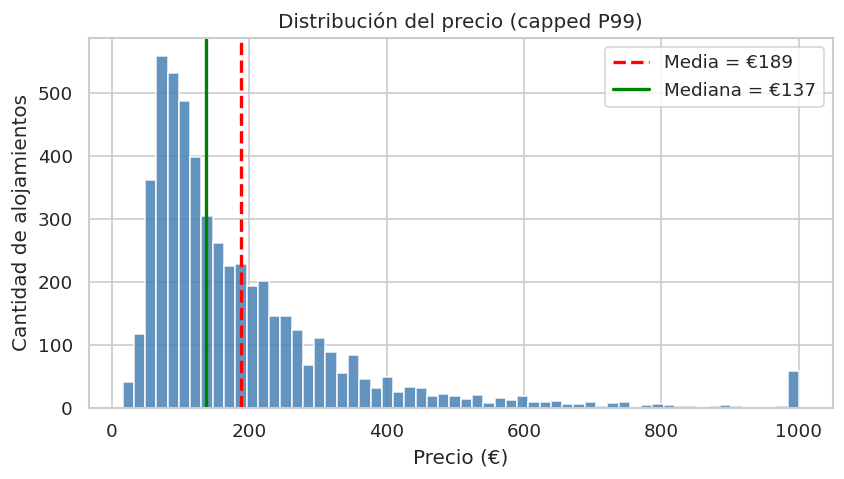

In [25]:
# Calcular la media y mediana de price_capped para marcarlas en el gráfico
media_cap  = df_clean['price_capped'].mean()
mediana_cap = df_clean['price_capped'].median()

plt.figure(figsize=(8, 4))
plt.hist(df_clean['price_capped'], bins=60, color='steelblue', alpha=0.85)

# Líneas verticales para media y mediana
plt.axvline(media_cap,   color='red',   linestyle='--', linewidth=2, label=f'Media = €{media_cap:.0f}')
plt.axvline(mediana_cap, color='green', linestyle='-',  linewidth=2, label=f'Mediana = €{mediana_cap:.0f}')

plt.title('Distribución del precio (capped P99)')
plt.xlabel('Precio (€)')
plt.ylabel('Cantidad de alojamientos')
plt.legend()
plt.show()

---
# 2.3.2 Precio capado - Boxplot

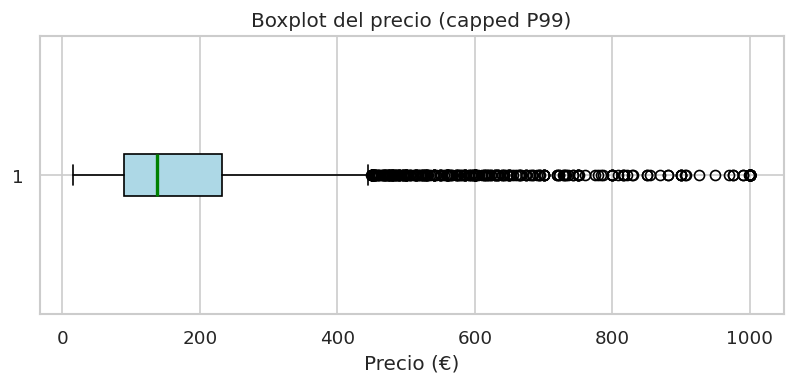

In [26]:
plt.figure(figsize=(8, 3))
plt.boxplot(df_clean['price_capped'], vert=False, patch_artist=True,
            boxprops=dict(facecolor='lightblue'),
            medianprops=dict(color='green', linewidth=2))
plt.title('Boxplot del precio (capped P99)')
plt.xlabel('Precio (€)')
plt.show()

---

**Interpretá:** 1. ¿La distribución sigue mostrando sesgo aunque aplicamos capping? 2. ¿Dónde está la mediana dentro de la caja del boxplot?

**1**
> Aunque el capping eliminó el efecto distorsionador de los valores extremadamente altos (como el máximo original de €19,140), el diagnóstico estadístico final confirma que la media (€189) sigue siendo mayor que la mediana (€137)

> Visualmente, el histograma capado muestra que la mayor parte de los alojamientos se concentran en precios bajos, con una "cola" que se extiende hacia los €1,000

**2**
> En el boxplot del precio capado, la línea verde que representa la mediana (€137) se encuentra desplazada hacia la izquierda dentro de la caja.
> La caja se extiende desde el primer cuartil (Q1 = €89) hasta el tercer cuartil (Q3 = €232).

> El hecho de que la mediana esté más cerca del límite izquierdo (Q1) que del derecho (Q3) es una evidencia visual clara de que los datos tienen un sesgo positivo, lo que significa que hay una mayor dispersión en los precios por encima de la mediana que por debajo de ella



---
# 2.4 Tipo de alojamiento

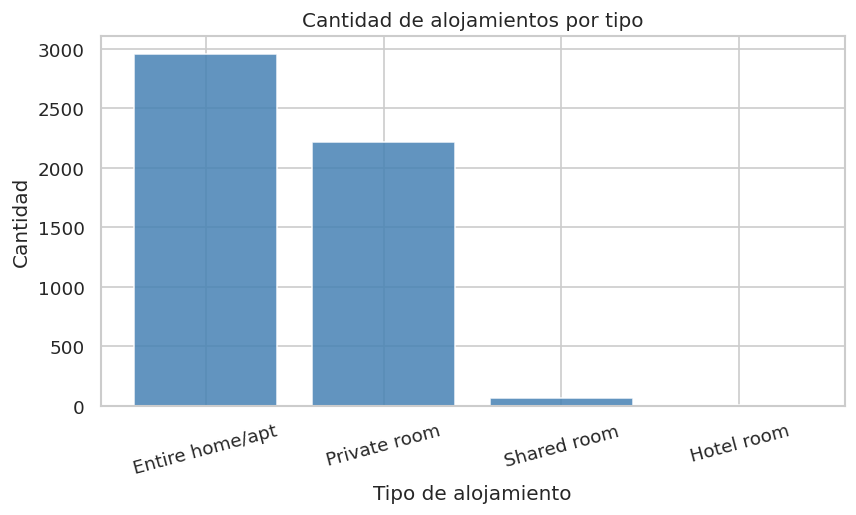

Proporciones por tipo:
room_type
Entire home/apt    56.4
Private room       42.3
Shared room         1.2
Hotel room          0.1
Name: count, dtype: float64


In [27]:
# Gráfico de barras para room_type
conteos = df_clean['room_type'].value_counts()

plt.figure(figsize=(8, 4))
plt.bar(conteos.index, conteos.values, color='steelblue', alpha=0.85)
plt.title('Cantidad de alojamientos por tipo')
plt.xlabel('Tipo de alojamiento')
plt.ylabel('Cantidad')
plt.xticks(rotation=15)
plt.show()

# Proporciones
print('Proporciones por tipo:')
proporciones = (conteos / len(df_clean) * 100).round(1)
print(proporciones)

---

# Bloque 3: EDA Bivariado

### Análisis por tipo de alojamiento, por barrio, correlación.





# 3.1 ¿Cómo varía el precio por tipo de alojamiento


In [28]:
# Estadísticas de precio para cada tipo de alojamiento
print('=== Precio (capped) por tipo de alojamiento ===')

estadisticas_tipo = df_clean.groupby('room_type')['price_capped'].agg(
    n='count',
    mediana='median',
    media='mean'
).sort_values('mediana', ascending=False).round(2)

print(estadisticas_tipo)

=== Precio (capped) por tipo de alojamiento ===
                    n  mediana   media
room_type                             
Entire home/apt  2958    207.0  253.81
Hotel room          3    188.0  186.67
Private room     2219     89.0  106.30
Shared room        64     43.0   55.80


/tmp/ipykernel_1255/3421946236.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(grupos, labels=etiquetas, vert=True, patch_artist=True)


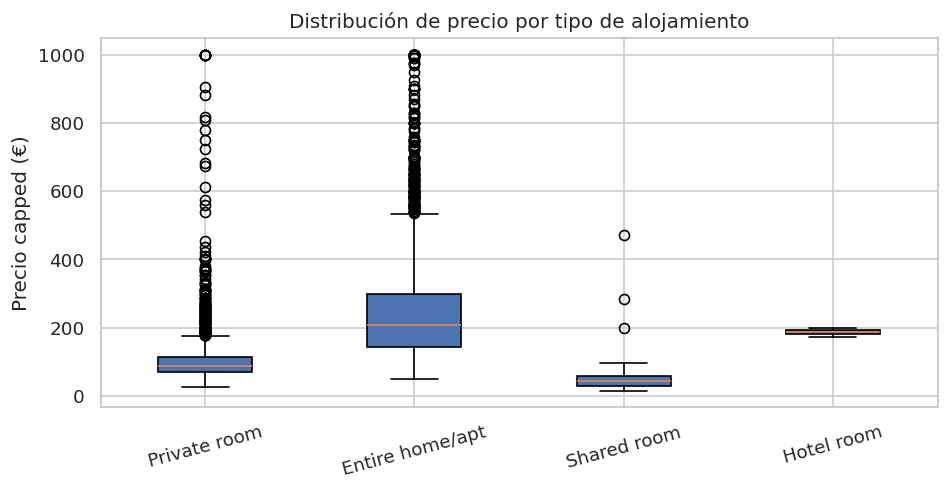

In [29]:
# Boxplot comparativo: precio por tipo de alojamiento
tipos = df_clean['room_type'].unique()

# Construir una lista con los precios de cada tipo
grupos = []
etiquetas = []

for tipo in tipos:
    precios_del_tipo = df_clean.loc[df_clean['room_type'] == tipo, 'price_capped']
    grupos.append(precios_del_tipo)
    etiquetas.append(tipo)

plt.figure(figsize=(9, 4))
plt.boxplot(grupos, labels=etiquetas, vert=True, patch_artist=True)
plt.xticks(rotation=15)
plt.ylabel('Precio capped (€)')
plt.title('Distribución de precio por tipo de alojamiento')
plt.show()

---

**Interpretá:** 1. ¿Cuál tipo tiene la mediana más alta? 2. ¿Y la mayor dispersión (IQR)? 3. ¿El `room_type` parece explicar parte de la diferencia de precios?

**1**
> El tipo de alojamiento con la mediana más alta es "Entire home/apt" (Casa/apto. entero) con €207.00

> Le sigue el "Hotel room" (€188), la "Private room" (€89) y, finalmente, el "Shared room" con la mediana más baja (€43).

**2**
> La mayor dispersión (representada por el tamaño de la caja en el boxplot) se observa claramente en "Entire home/apt". Esto indica que dentro de esta categoría los precios son muy variados, existiendo una diferencia considerable entre los alojamientos de este tipo.

> En contraste, las habitaciones compartidas y privadas muestran cajas mucho más comprimidas, lo que significa que sus precios son más homogéneos.

**3**
> El tipo de alojamiento es un factor determinante en el precio. La visualización muestra que las distribuciones de precios para cada categoría están situadas en niveles (escalones) muy diferentes del eje vertical.

> El hecho de que las medianas varíen drásticamente entre un "Shared room" (€43) y un "Entire home/apt" (€207) confirma que el mercado está fuertemente segmentado según el nivel de privacidad que ofrece el alojamiento.

# 3.2 ¿Cómo varía el precio por municipio?

In [92]:
# Estadísticas de precio por municipio (neighbourhood_group)
print('=== Precio por municipio (ordenado por mediana) ===')

estadisticas_municipio = df_clean.groupby('neighbourhood')['price_capped'].agg(
    n='count',
    mediana='median',
    media='mean'
).sort_values('mediana', ascending=False).round(2)

print(estadisticas_municipio)

=== Precio por municipio (ordenado por mediana) ===
                          n  mediana   media
neighbourhood                               
Dublin City            3501    150.0  199.48
Dn Laoghaire-Rathdown   622    137.0  194.11
Fingal                  695    108.0  166.68
South Dublin            426     91.5  131.07


# 3.3 ¿Hay relación entre variables numéricas?

###  Correlación de Pearson como diagnóstico

>  **Analogía geográfica:** la matriz de correlación es como superponer todas las capas raster de a dos para ver cuáles se relacionan.

El coeficiente r mide la relación lineal entre dos variables (−1 a +1).

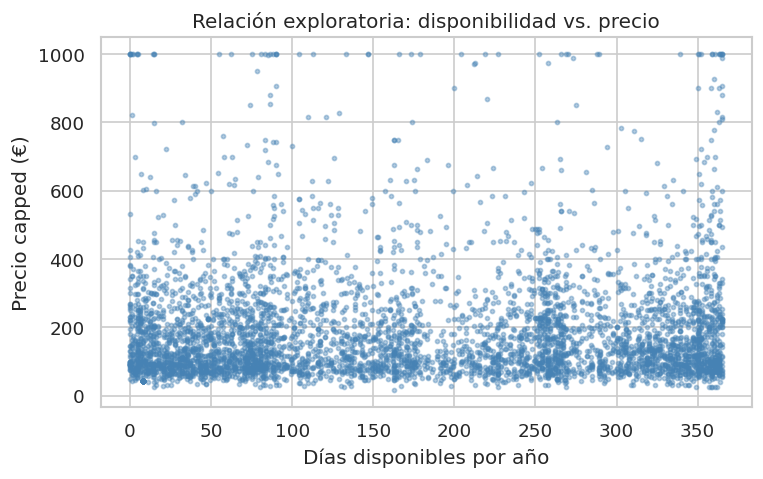

In [31]:
# Scatter: ¿hay relación entre precio y disponibilidad?
# Usamos 5000 puntos para que el gráfico no quede saturado
muestra = df_clean.sample(n=5000, random_state=7)

plt.figure(figsize=(7, 4))
plt.scatter(muestra['availability_365'], muestra['price_capped'],
            s=6, alpha=0.4, color='steelblue')
plt.xlabel('Días disponibles por año')
plt.ylabel('Precio capped (€)')
plt.title('Relación exploratoria: disponibilidad vs. precio')
plt.show()

**¿Creés que hay relación entre disponibilidad y precio?**
> No parece haber una relación clara entre estas variables. El gráfico de dispersión muestra puntos distribuidos por todo el plano sin una tendencia definida, y la matriz de correlación confirma esto con un coeficiente de apenas 0.01, lo que indica una relación lineal casi nula.

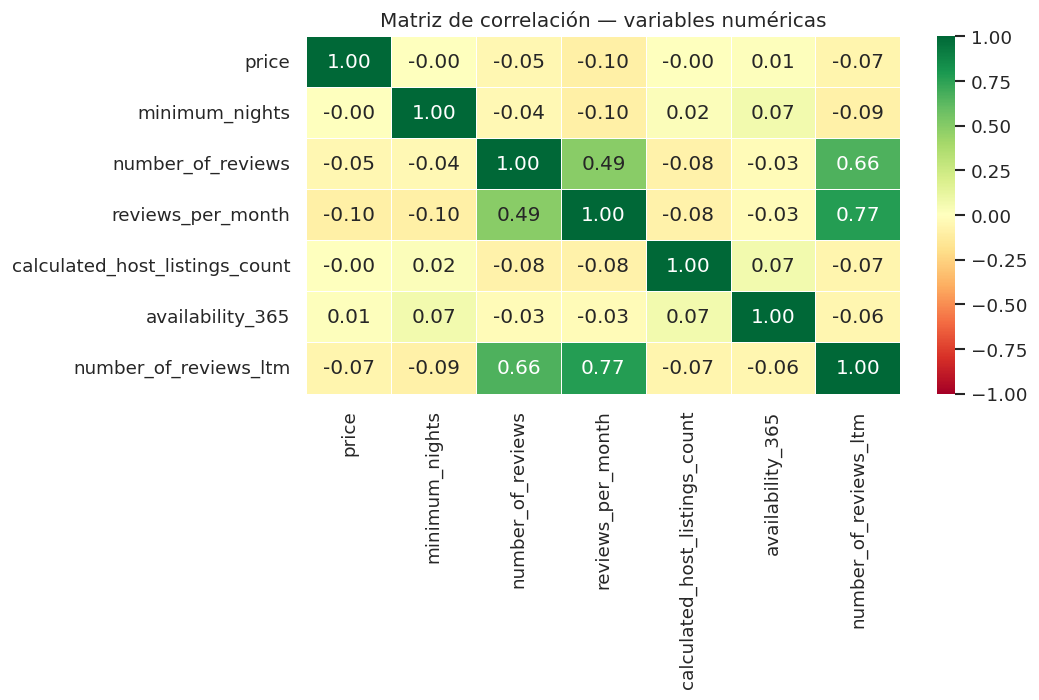

In [32]:
# Calcular la matriz de correlación
correlaciones = df_clean[num_cols].corr(numeric_only=True).round(2)

# Visualizar con seaborn (mucho más simple que matplotlib)
plt.figure(figsize=(9, 6))
sns.heatmap(
    correlaciones,
    annot=True,        # mostrar los números dentro de las celdas
    fmt='.2f',         # formato: 2 decimales
    cmap='RdYlGn',     # paleta: rojo → amarillo → verde
    vmin=-1, vmax=1,   # escala fija entre -1 y 1
    linewidths=0.5
)
plt.title('Matriz de correlación — variables numéricas')
plt.tight_layout()
plt.show()

---
**¿Qué par de variables tiene la correlación más alta? ¿Tiene sentido geográficamente?**
> El par con la correlación más alta es reviews_per_month y number_of_reviews_ltm (0.77)
> Geográficamente tiene sentido porque ambos son indicadores de actividad y demanda del mercado; los alojamientos que reciben muchas reseñas mensualmente tienden a ser los mismos que han tenido un alto volumen de actividad en los últimos 12 meses.

1. ¿Cuál tipo de alojamiento domina la oferta? ¿Cómo afecta eso al precio promedio general?
   > Domina el tipo "Entire home/apt" (Casa/apto. entero) con un 56.4% de la oferta total.

   > Al ser el tipo de alojamiento significativamente más caro (mediana de €207) en comparación con las habitaciones privadas (€89) o compartidas (€43), su predominancia empuja el precio promedio general hacia arriba, elevando el costo típico de la ciudad

2. ¿El municipio de Dublin (Dublin City) tiene la mediana más alta? ¿Lo esperabas?
   > Aunque la tabla por municipio aparece vacía en un segmento del código
, los datos de frecuencia muestran que Dublin City concentra la gran mayoría de la oferta con 3,501 alojamientos.

  > En mercados de Airbnb, es usual esperar que el centro urbano principal (Dublin City) tenga precios elevados debido a la cercanía con servicios y puntos de interés turístico.

3. Si quisieras saber si los precios altos se *concentran geográficamente* en ciertas zonas, ¿qué tipo de análisis necesitarías?
   > Se necesitaría realizar un ESDA (Análisis Exploratorio de Datos Espaciales). Mientras que el EDA analiza la estadística descriptiva, el ESDA permite identificar patrones en el espacio y responder preguntas sobre la concentración territorial (clústeres) de valores mediante mapas de calor, densidad o análisis de autocorrelación espacial.

# Generar el dataset limpio para la parte 2

In [33]:
# Seleccionar las columnas que necesitamos para la Parte 2
columnas_finales = [
    'id', 'host_id',
    'neighbourhood_group', 'neighbourhood', 'room_type',
    'latitude', 'longitude',
    'price', 'price_capped', 'price_log10',
    'minimum_nights', 'minimum_nights_capped',
    'number_of_reviews', 'number_of_reviews_ltm', 'reviews_per_month',
    'calculated_host_listings_count', 'availability_365',
    'last_review', 'license'
]

df_final = df_clean[columnas_finales].copy()

print('Dataset final:', df_final.shape[0], 'filas ·', df_final.shape[1], 'columnas')

Dataset final: 5244 filas · 19 columnas


In [34]:
# Guardar el dataset limpio como CSV
# index=False → no incluir la numeración interna de pandas en el archivo
df_final.to_csv('Dubling_listings_clean.csv', index=False)

print('✓ Archivo guardado: Dubling_listings_clean.csv')
print('  Este archivo es el insumo de la Parte 2 (ESDA).')
print()
df_final.head(3)

✓ Archivo guardado: Dubling_listings_clean.csv
  Este archivo es el insumo de la Parte 2 (ESDA).



,id,host_id,neighbourhood_group,neighbourhood,room_type,latitude,longitude,price,price_capped,price_log10,minimum_nights,minimum_nights_capped,number_of_reviews,number_of_reviews_ltm,reviews_per_month,calculated_host_listings_count,availability_365,last_review,license
0,44077,193005,NaN,Dn Laoghaire-Rathdown,Private room,53.29178,-6.25792,86.0,86.0,1.934498,3,3,394,37,2.23,2,9,2025-09-13,NaN
2,159889,766611,NaN,Dublin City,Private room,53.39027,-6.23547,48.0,48.0,1.681241,2,2,464,20,2.82,3,312,2025-09-14,NaN
3,162809,777681,NaN,Dn Laoghaire-Rathdown,Private room,53.28326,-6.19188,101.0,101.0,2.004321,2,2,397,8,3.17,2,7,2025-09-11,NaN


In [35]:
# Resumen diagnóstico final
pct_outliers = ((df_clean['price'] > Q3 + 1.5 * IQR).sum() / len(df_clean)) * 100
pct_nulos    = (df_original['price'].isna().sum() / len(df_original)) * 100

print('======================================================')
print('   DIAGNÓSTICO EDA — PRECIO POR NOCHE EN DUBLIN')
print('======================================================')
print('  N total:                ', len(df_original))
print('  N válidos (con precio): ', len(df_clean))
print(f'  Nulos en price:          {pct_nulos:.1f}%')
print()
print(f'  Media:                   €{media:.2f}')
print(f'  Mediana:                 €{mediana:.2f}')
print(f'  Desv. estándar:          €{std:.2f}')
print(f'  IQR:                     €{IQR:.2f}')
print(f'  Skewness:                {skew:.2f}')
print(f'  Outliers moderados:      {pct_outliers:.1f}%')
print()
print('  IMPLICACIONES CARTOGRÁFICAS:')

if skew > 1:
    print(f'  → Sesgo POSITIVO ({skew:.1f}) — NO usar intervalos iguales')
    print('    Recomendado: cuantiles o transformación log10')

if std > media:
    print('  → SD > Media — la media por barrio sobreestima el precio típico')
    print('    Usar mediana o price_capped')

if pct_outliers > 5:
    print(f'  → {pct_outliers:.1f}% de outliers — usar price_capped para visualización')

print('======================================================')

   DIAGNÓSTICO EDA — PRECIO POR NOCHE EN DUBLIN
  N total:                 6945
  N válidos (con precio):  5244
  Nulos en price:          24.5%

  Media:                   €204.50
  Mediana:                 €137.00
  Desv. estándar:          €400.98
  IQR:                     €143.00
  Skewness:                26.85
  Outliers moderados:      6.3%

  IMPLICACIONES CARTOGRÁFICAS:
  → Sesgo POSITIVO (26.9) — NO usar intervalos iguales
    Recomendado: cuantiles o transformación log10
  → SD > Media — la media por barrio sobreestima el precio típico
    Usar mediana o price_capped
  → 6.3% de outliers — usar price_capped para visualización


---

# Bloque 4: ESDA Espacial

### Mapa de puntos, densidad, spatial join, coroplético



## 4.1. Carga de librerías y lectura del archivo base


In [36]:
!pip -q install pandas numpy matplotlib geopandas shapely plotly ipywidgets requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 25.1 MB/s eta 0:00:00


In [37]:
# =========================
# Importar librerias
# =========================
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

pd.set_option("display.max_columns", 200)

# =========================
# Importar documento limpio
# =========================
df = pd.read_csv('Dubling_listings_clean.csv')
print("Datos cargados desde Dubling_listings_clean.csv")

Datos cargados desde Dubling_listings_clean.csv


## 4.2.  Verificación de columnas de coordenadas

Antes de construir la capa espacial, este bloque identifica cuáles columnas contienen la latitud y la longitud. Esta validación evita errores posteriores al crear las geometrías.


In [38]:
# ==========================================
# Verificar que las columnas existan
# ==========================================

possible_lat = [c for c in df.columns if c.lower() in ["lat", "latitude", "y"]]
possible_lon = [c for c in df.columns if c.lower() in ["lon", "lng", "longitude", "x"]]

print("\nPosibles columnas de latitud:", possible_lat)
print("Posibles columnas de longitud:", possible_lon)

# Si ya sabes que se llaman 'latitude' y 'longitude', fuerza:
lat_col = "latitude" if "latitude" in df.columns else possible_lat[0]
lon_col = "longitude" if "longitude" in df.columns else possible_lon[0]

print(f"\nUsando lat={lat_col} | lon={lon_col}")

# Chequeo de nulos y rangos (sanity check)
print("\nNulos en lat/lon:")
print(df[[lat_col, lon_col]].isna().sum())


Posibles columnas de latitud: ['latitude']
Posibles columnas de longitud: ['longitude']

Usando lat=latitude | lon=longitude

Nulos en lat/lon:
latitude     0
longitude    0
dtype: int64


## 4.3.  Conversión a GeoDataFrame

Aquí la tabla se transforma en un objeto espacial a partir de las coordenadas, generando geometrías de tipo punto y asignando el sistema de referencia *EPSG:4326*.

#####  nota: el 4326 es el codigo de la WGS84, para que se asigne por medio de GeoPanda la proyeccion a la capa/tabla.

In [39]:
# ======================================
#Convertir a GeoDataFrame de puntos
# ======================================
# CRS: WGS84 (EPSG:4326) típico para lat/lon
gdf_airbnb = gpd.GeoDataFrame(
    df.copy(),
    geometry=gpd.points_from_xy(df[lon_col], df[lat_col]),
    crs="EPSG:4326"
)

print("\nGeoDataFrame Airbnb ✅")
print("CRS:", gdf_airbnb.crs)
display(gdf_airbnb.head(3)[[lat_col, lon_col, "geometry"]])


GeoDataFrame Airbnb ✅
CRS: EPSG:4326


,latitude,longitude,geometry
0,53.29178,-6.25792,POINT (-6.25792 53.29178)
1,53.39027,-6.23547,POINT (-6.23547 53.39027)
2,53.28326,-6.19188,POINT (-6.19188 53.28326)


## 4.4. Visualizar datos
### 4.4.1. Visualización interactiva inicial

Este mapa representa los registros de Airbnb como puntos sobre un mapa base. Su función es ofrecer una primera lectura espacial del fenómeno.


In [52]:

import plotly.express as px
hover_cols = [c for c in ["price", "room_type", "neighbourhood", "reviews_per_month"] if c in gdf_airbnb.columns]  #Para generar el grafico utlizamos plotly y elegimos las columnas que se quieren ver en las etiquetas de cada uno de los puntos.

fig = px.scatter_mapbox(
    gdf_airbnb,
    lat=lat_col,
    lon=lon_col,
    hover_name=hover_cols[0] if hover_cols else None,
    hover_data=hover_cols if hover_cols else None,
    zoom=11,
    height=600
)

fig.update_layout(
    mapbox_style="carto-darkmatter",
    margin={"r":0,"t":0,"l":0,"b":0}  #carto-darkmatter, carto-positron son otras dos opciones de mapas bases!!
)

fig.show()

### 4.5. Visualización estática por categorías

En esta sección se representan los puntos con colores diferenciados según *neighbourhood_group*, facilitando una lectura descriptiva de la distribución territorial.


In [41]:
print(df.columns)

Index(['id', 'host_id', 'neighbourhood_group', 'neighbourhood', 'room_type',
       'latitude', 'longitude', 'price', 'price_capped', 'price_log10',
       'minimum_nights', 'minimum_nights_capped', 'number_of_reviews',
       'number_of_reviews_ltm', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365', 'last_review',
       'license'],
      dtype='object')


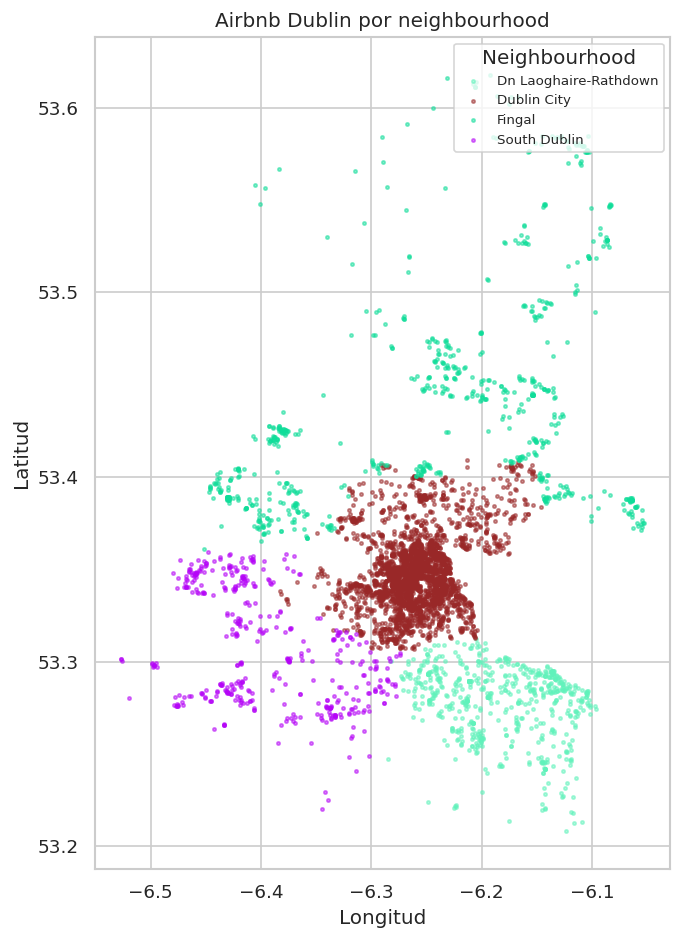

In [42]:
import matplotlib.pyplot as plt #Esta esta generando una figura estatica con leyenda de todos los puntos dentro del dataset.
import numpy as np
import matplotlib.colors as mcolors

# Copia para evitar tocar el original
gdf_plot = gdf_airbnb.copy()

# Quitar nulos en la columna de interés si existen
gdf_plot = gdf_plot[gdf_plot["neighbourhood"].notna()].copy()

# Categorías únicas
cats = sorted(gdf_plot["neighbourhood"].unique())

# Semilla para que los colores aleatorios sean reproducibles
np.random.seed(42)

# Generar colores aleatorios
random_colors = np.random.rand(len(cats), 3)

# Diccionario categoría -> color
color_dict = {cat: random_colors[i] for i, cat in enumerate(cats)}

# Asignar color a cada fila
gdf_plot["color"] = gdf_plot["neighbourhood"].map(color_dict)

# Graficar
fig, ax = plt.subplots(figsize=(9, 9))

for cat in cats:
    subset = gdf_plot[gdf_plot["neighbourhood"] == cat]
    subset.plot(
        ax=ax,
        color=color_dict[cat],
        markersize=4,
        alpha=0.5,
        label=cat
    )

ax.set_title("Airbnb Dublin por neighbourhood")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.legend(title="Neighbourhood", loc="upper right", fontsize=8)
plt.show()

### 4.6. Visualización espacial del precio

Este bloque representa la variable *price* mediante una escala continua de color para explorar contrastes y patrones espaciales del precio.

In [53]:
import geopandas as gpd
from shapely.geometry import Point
import plotly.express as px

# Re-create gdf_airbnb from df, which now contains 'price_capped' after loading Dubling_listings_clean.csv
# Assuming lat_col and lon_col are already defined correctly from previous cells
gdf_airbnb = gpd.GeoDataFrame(
    df.copy(),
    geometry=gpd.points_from_xy(df[lon_col], df[lat_col]),
    crs="EPSG:4326"
)

fig = px.scatter_mapbox(
    gdf_airbnb,
    lat=lat_col,
    lon=lon_col,
    color="price_capped",
    color_continuous_scale="Viridis",  # puedes cambiar paleta (la del costado derecho que va en degradado) hay otras como: Plasma, Magma, Cividis, Spectral,
    hover_data=hover_cols if hover_cols else None,
    zoom=11,
    height=600
)

fig.update_layout(
    mapbox_style="carto-darkmatter",
    margin={"r":0,"t":0,"l":0,"b":0}
)

fig.show()

> Como mencionamos anteriormente, si no comprendemos nuestros datos, corremos el riesgo de que no comuniquen nada. Una alternativa valiosa, especialmente cuando no deseamos eliminar o descartar los valores extremos (outliers), es ofrecer flexibilidad en la visualización. En muchos dashboards o geovisores, la intención no es ocultar información, sino permitir al usuario filtrar los rangos de visualización para explorar el fenómeno a distintas escalas. Aunque todavía no estamos en este tema, podemos ir reflexionando al respecto.

#4.7 no fue solucionado por lo que no lo inclui en el laboratorio

### 4.8. Mapas de densidad

Un mapa de calor (o mapa de densidad) es una herramienta visual que utiliza colores para representar la intensidad de un fenómeno en puntos específicos de un gráfico o mapa. En lugar de mostrar puntos individuales que podrían amontonarse y ser difíciles de leer, estos mapas agrupan los datos: las zonas con mayor/alta concentración y baja concentración.

Esencialmente, sirven para identificar patrones y "puntos calientes" de forma inmediata. Se usan mucho en meteorología para mostrar temperaturas, en sitios web para ver dónde hacen clic los usuarios, o en urbanismo para detectar las calles con más tráfico,entre muchas otras cosas más. Es la forma más sencilla de convertir una montaña de datos complejos en una imagen intuitiva que cualquiera puede entender de un vistazo

In [54]:
#Mapa de calor

fig = px.density_mapbox(
    gdf_airbnb,
    lat=lat_col,
    lon=lon_col,
    z="price_capped",
    radius=12,
    center=dict(lat=gdf_airbnb[lat_col].mean(), lon=gdf_airbnb[lon_col].median()),
    zoom=11,
    mapbox_style="carto-darkmatter",
    height=600
)

fig.show()

### 4.9. Mapas de agrupación hexagonal

Otra alternativa son los hexbins (o mapas de agrupación hexagonal) son una variante de los mapas de calor que, en lugar de usar manchas difusas, dividen el espacio en una cuadrícula de hexágonos perfectos. Cada hexágono actúa como un **contenedor** que cambia de color según la cantidad de puntos de datos que caen dentro de él. Es como pixelar un mapa, pero usando figuras de seis lados para organizar la información de manera más ordenada y geométrica.

Se prefieren los hexágonos sobre los cuadrados tradicionales por una razón técnica ingeniosa: la simetría. Al tener seis lados, el centro de un hexágono está a una distancia más uniforme de los centros de sus vecinos que en una cuadrícula cuadrada. Esto reduce la distorsión visual y ayuda a representar mejor la densidad real de los datos, evitando que el ojo humano se distraiga con las líneas rectas verticales y horizontales.

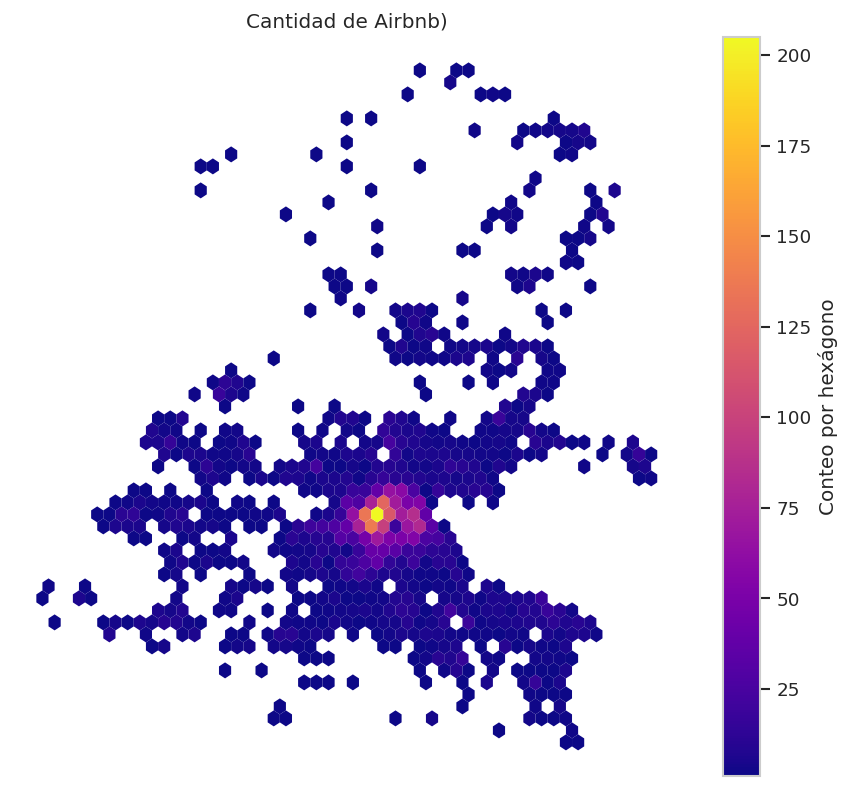

In [46]:
import matplotlib.pyplot as plt

# 1) Proyectar puntos a metros (mejor para hexbins) #el WGS84 trabaja en radianes, al pasarlo al Web Mercator.
gdf_m = gdf_airbnb.to_crs(epsg=3857)

x = gdf_m.geometry.x
y = gdf_m.geometry.y

fig, ax = plt.subplots(1, 1, figsize=(9, 8))

hb = ax.hexbin( #Aqui se esta definiendo el tamaño del hexagono
    x, y,
    gridsize=50,     # ajusta: 40-120 según detalle deseado del hexagono, entre mas chiquito el hexagono es mas preciso el dato que se esta leyendo.
    mincnt=1,
    linewidths=0,
    cmap="plasma"  #Aca se le esta asignando el color a los hexagonos
)

ax.set_title("Cantidad de Airbnb)")
ax.set_axis_off()
cb = fig.colorbar(hb, ax=ax)
cb.set_label("Conteo por hexágono")
plt.show()

En esta variante, los hexágonos no solo agrupan puntos, sino que también resumen una variable cuantitativa asociada a ellos.


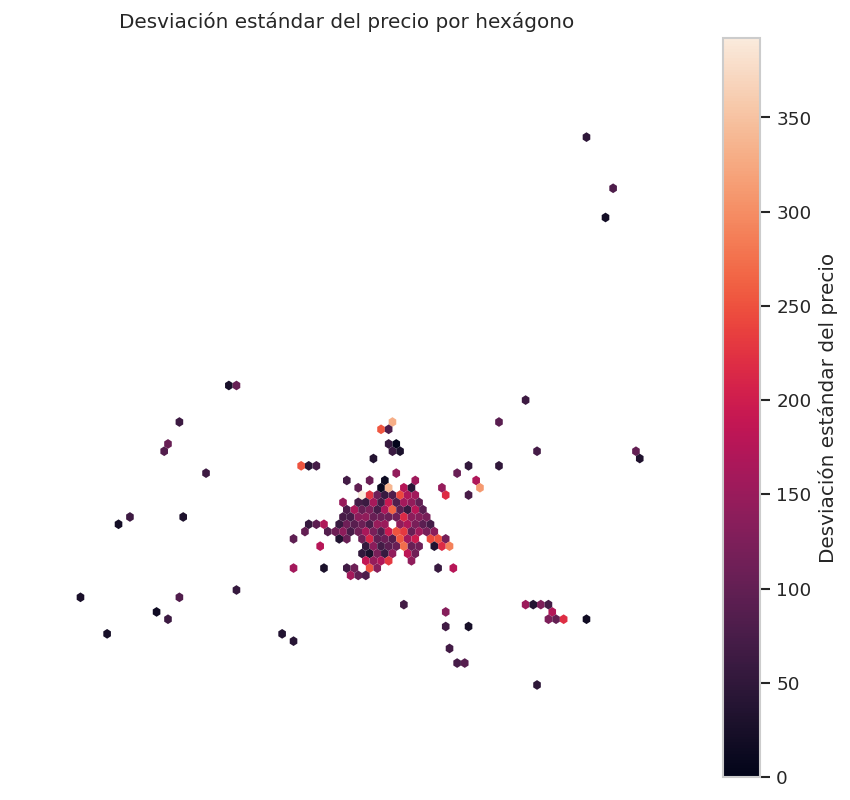

In [47]:
import numpy as np
import matplotlib.pyplot as plt

gdf_m = gdf_airbnb.dropna(subset=["price_capped"]).to_crs(epsg=3857)
x = gdf_m.geometry.x
y = gdf_m.geometry.y
c = gdf_m["price_capped"].to_numpy()

fig, ax = plt.subplots(1, 1, figsize=(9, 8))

hb = ax.hexbin(
    x, y,
    C=c,
    reduce_C_function=np.std,   # acá pueden cambiar la estadística
    gridsize=80,
    mincnt=6,
    linewidths=0
)

ax.set_title("Desviación estándar del precio por hexágono")
ax.set_axis_off()
cb = fig.colorbar(hb, ax=ax)
cb.set_label("Desviación estándar del precio")
plt.show()

## 4.10. Análisis por unidades político-administrativas.

Si bien los datos de puntos traen información político administrativa, puntualmente en las columnas neighbourhood (Freguesias) y neighbourhood_group (Municipios). No podemos hacer nada más que análisis tabulares. Por esa razón, agregaremos esta información en forma de polígonos y realizaremos una unión (join) entre ambas bases de datos.

##4.10.1. Incorporación de unidades político-administrativas

Aquí se carga la capa poligonal de comunas para contextualizar los puntos y permitir agregaciones territoriales.


In [70]:
import geopandas as gpd

geojson_url = "https://raw.githubusercontent.com/Milariano/Datos-de-Dublin-CamilaRR-C36535/refs/heads/main/neighbourhoods.geojson"

gdf_comunas = gpd.read_file(geojson_url)

print("GeoJSON cargado ✅")
print("Filas, columnas:", gdf_comunas.shape) #que indique las columnas
print("CRS:", gdf_comunas.crs) #que imprima la proyección del archivo
print("\nColumnas:")
print(gdf_comunas.columns.tolist())

display(gdf_comunas.head(5))



GeoJSON cargado ✅
Filas, columnas: (4, 3)
CRS: EPSG:4326

Columnas:
['neighbourhood', 'neighbourhood_group', 'geometry']


,neighbourhood,neighbourhood_group,geometry
0,Dublin City,None,"MULTIPOLYGON (((-6.22569 53.41099, -6.22295 53..."
1,South Dublin,None,"MULTIPOLYGON (((-6.41219 53.3678, -6.40812 53...."
2,Fingal,None,"MULTIPOLYGON (((-6.20563 53.46745, -6.20516 53..."
3,Dn Laoghaire-Rathdown,None,"MULTIPOLYGON (((-6.12869 53.29203, -6.1283 53...."


### 4.10.2 Visualización estática de la capa poligonal

Este mapa permite reconocer la estructura espacial de las unidades administrativas y verificar visualmente que la capa fue cargada correctamente.


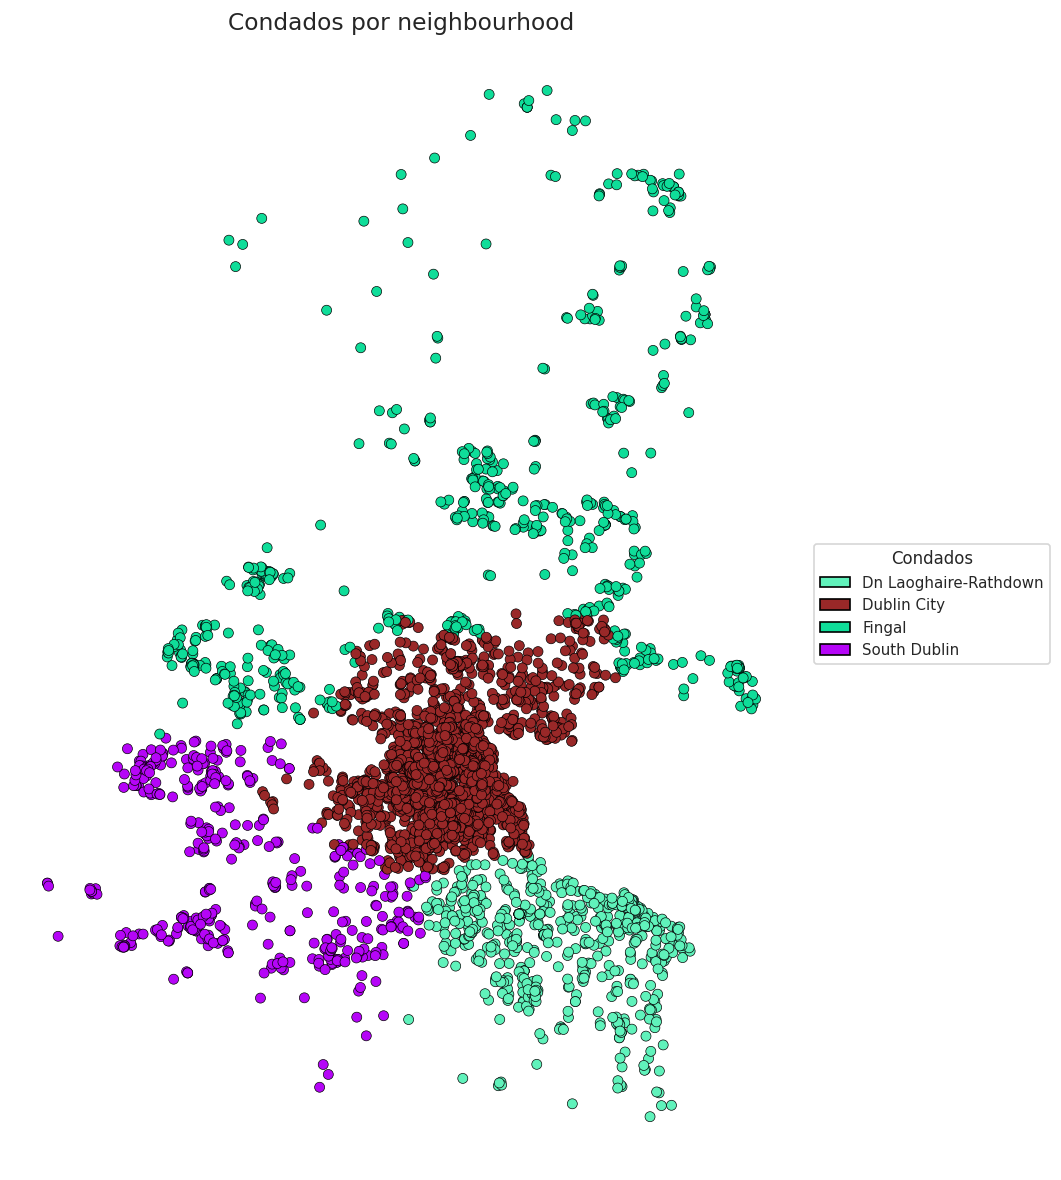

In [71]:
import matplotlib.pyplot as plt #Es basicamente imprimir el mapa.
import numpy as np
from matplotlib.patches import Patch

gdf_plot = gdf_airbnb.copy()
col = "neighbourhood"

# Filtrar nulos
gdf_plot = gdf_plot[gdf_plot[col].notna()].copy()

# Categorías
cats = sorted(gdf_plot[col].unique())

# Colores aleatorios reproducibles
np.random.seed(42)
colors = np.random.rand(len(cats), 3)
color_dict = {cat: colors[i] for i, cat in enumerate(cats)}

# Asignar color
gdf_plot["color"] = gdf_plot[col].map(color_dict)

# Graficar
fig, ax = plt.subplots(figsize=(10, 10))

gdf_plot.plot(
    ax=ax,
    color=gdf_plot["color"],
    edgecolor="black",
    linewidth=0.4
)

ax.set_title("Condados por neighbourhood", fontsize=14)
ax.set_axis_off()

legend_elements = [
    Patch(facecolor=color_dict[cat], edgecolor="black", label=str(cat))
    for cat in cats
]

ax.legend(
    handles=legend_elements,
    title="Condados",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=9,
    title_fontsize=10,
    frameon=True
)

plt.tight_layout()
plt.show()

### 4.11. Visualización interactiva de polígonos

En este bloque se genera un mapa interactivo de los condados, preparando la base para representaciones agregadas o coropléticas.


In [93]:
import geopandas as gpd #Esto es un mapa interactivo
import plotly.express as px

gdf_plot = gdf_comunas.copy()
gdf_plot = gdf_plot[gdf_plot["neighbourhood"].notna()].copy() #Indicamos cual es la capa que se quiera visualizar

# Asegurar WGS84
if gdf_plot.crs is not None and gdf_plot.crs.to_epsg() != 4326:
    gdf_plot = gdf_plot.to_crs(epsg=4326)

# Simplificar geometrías para aligerar
gdf_plot["geometry"] = gdf_plot.geometry.simplify(0.0005, preserve_topology=True)

# ID único
gdf_plot = gdf_plot.reset_index(drop=True)
gdf_plot["id_plotly"] = gdf_plot.index.astype(str)

geojson_data = gdf_plot.__geo_interface__

xmin, ymin, xmax, ymax = gdf_plot.total_bounds
center = {"lat": (ymin + ymax) / 2, "lon": (xmin + xmax) / 2}

fig = px.choropleth_mapbox( #Aqui comienza el proceso de diseño del mapa
    gdf_plot,
    geojson=geojson_data,
    locations="id_plotly",
    featureidkey="properties.id_plotly",
    color="neighbourhood",
    hover_name="neighbourhood",
    hover_data={"neighbourhood": True, "id_plotly": False},
    mapbox_style="carto-positron",
    center=center,
    zoom=8.8,
    opacity=0.65
)

fig.update_layout(
    title="Mapa interactivo de neighbourhood",
    margin={"r": 0, "t": 40, "l": 0, "b": 0},
    showlegend=False
)

fig.show()

### 4.12 Preparación para la unión espacial

1.   Elemento de la lista
2.   Elemento de la lista



Esta parte marca la transición hacia la integración espacial entre la capa de puntos y la capa poligonal.


In [73]:
#Librerias para el join

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

#### 4.12.1 Verificaciones previas al join

Antes de unir ambas capas, se comprueba el CRS, la validez de las geometrías y el estado de variables clave como el precio.

In [74]:
# Verificación de AIRBNB
print("CRS puntos Airbnb:", gdf_airbnb.crs) #En estas dos estamos pidiendo impresion de datos del dataset base
print("CRS comunas:", gdf_comunas.crs)# En esta se esta cargando la informacion el GeoJaison

# Igualar CRS si hace falta
if gdf_airbnb.crs != gdf_comunas.crs:
    gdf_airbnb = gdf_airbnb.to_crs(gdf_comunas.crs)

# Filtrar registros válidos
gdf_airbnb = gdf_airbnb[gdf_airbnb.geometry.notna()].copy() #Se realiza una verificacion de que no hayan duplicas o errores en los datos
gdf_comunas = gdf_comunas[gdf_comunas.geometry.notna()].copy()

# Verificar columna de precio
print(gdf_airbnb["price_capped"].dtype)
print(gdf_airbnb["price_capped"].isna().sum(), "NA en price_capped")

CRS puntos Airbnb: EPSG:4326
CRS comunas: EPSG:4326
float64
0 NA en price_capped


#### 4.12.2 Implementación del *spatial join*

Aquí se ejecuta la unión espacial entre los puntos de Airbnb y los polígonos administrativos usando el predicado `within`.


In [75]:
#IMPLEMENTACIÓN/EJECUCIÓN DEL JOIN
# Mantener solo columnas relevantes del polígono
cols_poly = ["neighbourhood_group", "neighbourhood", "geometry"] #Se dejan al analisis unicamente las columnas que nos interesan.
gdf_poly = gdf_comunas[cols_poly].copy()

# Unión espacial
gdf_join = gpd.sjoin( #Se pide que haga el join de airbnb, poly y el left indica que se conserven todos los puntos incluso si no tienen poligono asignado.
    gdf_airbnb, #Capa de puntos airbnb, es decir la del dataset
    gdf_poly, #esta viene del Geojaison o comunas.
    how="left", #Si quiero dejar aquellos puntos que no caen en ningun poligono usamos #inner. #how significa tipo de join
    predicate="within" #Que se encuentren contenidos. #la relacion espacial para determinar el match. segun las intrucciones de "within" o "intersects" en este ultimo basta que toque aunque sea un poco el poligono0
) #En estas se verifica, imprimiendo cuantos datos de cada uno se cargaron y si quedaron variables sin poligonos.

print("Registros Airbnb:", len(gdf_airbnb))
print("Registros tras sjoin:", len(gdf_join))
print("Sin polígono asignado (NA neighbourhood_group):", gdf_join["neighbourhood_group_right"].isna().sum())
print("Sin polígono asignado (NA neighbourhood):", gdf_join["neighbourhood_right"].isna().sum())

Registros Airbnb: 5244
Registros tras sjoin: 5244
Sin polígono asignado (NA neighbourhood_group): 5244
Sin polígono asignado (NA neighbourhood): 0


### 4.13 Resumen estadístico por municipio

Este bloque calcula estadísticas descriptivas por *neighbourhood_group*, permitiendo comparar municipios en términos de cantidad de registros y precios.

In [83]:
 #Ahora se analiza y se generan estadisticas apartir de la informacion de arriba
res_ng = ( #Es basicamente un resumen estadistico
    gdf_join
    .dropna(subset=["neighbourhood_right", "price_capped"])
    .groupby("neighbourhood_right")
    .agg(
        airbnbs=("price_capped", "size"),
        precio_promedio=("price_capped", "mean"), #calcula la media
        precio_mediana=("price_capped", "median"), #calcula el promedio
        precio_std=("price_capped", "std"),
        precio_min=("price_capped", "min"),
        precio_max=("price_capped", "max")
    )
    .reset_index()
    .sort_values("precio_promedio", ascending=False) #Sort lo que hace es ordenar de mayor a menor los datos.
)

display(res_ng)

,neighbourhood_right,airbnbs,precio_promedio,precio_mediana,precio_std,precio_min,precio_max
1,Dublin City,3501,199.479006,150.0,162.115771,16.0,1000.0
0,Dn Laoghaire-Rathdown,622,194.106109,137.0,160.713911,34.0,1000.0
2,Fingal,695,166.683453,108.0,162.958218,26.0,1000.0
3,South Dublin,426,131.065728,91.5,106.464887,30.0,1000.0


¿Qué vemos en los datos tabulares?
> Se puede observar la informacion de los 5 condados con los precios mas altos en Dublin, Ireland.

### 4.13.1. Resumen estadístico por condado
Aquí se replica la lógica anterior a una escala más detallada: * neighbourhood* para una lectura territorial más fina.

In [78]:
res_n = (
    gdf_join
    .dropna(subset=["neighbourhood_right", "price_capped"])
    .groupby("neighbourhood_right")
    .agg(
        airbnbs=("price_capped", "size"),
        precio_promedio=("price_capped", "mean"),
        precio_mediana=("price_capped", "median"),
        precio_std=("price_capped", "std"),
        precio_min=("price_capped", "min"),
        precio_max=("price_capped", "max")
    )
    .reset_index()
    .sort_values("precio_promedio", ascending=False)
)

display(res_n.head(10))
display(res_n.tail(10))

if not res_n.empty:
    mas_caro = res_n.iloc[0]
    mas_barato = res_n.iloc[-1]

    print("Neighbourhood más caro:")
    print(mas_caro[["neighbourhood_right", "precio_promedio", "airbnbs"]])

    print("\nNeighbourhood más barato:")
    print(mas_barato[["neighbourhood_right", "precio_promedio", "airbnbs"]])
else:
    print("El DataFrame 'res_n' está vacío. No se encontraron alojamientos dentro de los 'neighbourhoods' después del join y filtrado.")

,neighbourhood_right,airbnbs,precio_promedio,precio_mediana,precio_std,precio_min,precio_max
1,Dublin City,3501,199.479006,150.0,162.115771,16.0,1000.0
0,Dn Laoghaire-Rathdown,622,194.106109,137.0,160.713911,34.0,1000.0
2,Fingal,695,166.683453,108.0,162.958218,26.0,1000.0
3,South Dublin,426,131.065728,91.5,106.464887,30.0,1000.0


,neighbourhood_right,airbnbs,precio_promedio,precio_mediana,precio_std,precio_min,precio_max
1,Dublin City,3501,199.479006,150.0,162.115771,16.0,1000.0
0,Dn Laoghaire-Rathdown,622,194.106109,137.0,160.713911,34.0,1000.0
2,Fingal,695,166.683453,108.0,162.958218,26.0,1000.0
3,South Dublin,426,131.065728,91.5,106.464887,30.0,1000.0


Neighbourhood más caro:
neighbourhood_right    Dublin City
precio_promedio         199.479006
airbnbs                       3501
Name: 1, dtype: object

Neighbourhood más barato:
neighbourhood_right    South Dublin
precio_promedio          131.065728
airbnbs                         426
Name: 3, dtype: object


> Se puede concluir que el condado mas caro es Dublin City con 3501 airbns.


### 4.13.2 Filtrado por número mínimo de observaciones

Este bloque restringe el análisis a unidades con al menos 10 registros para mejorar la robustez descriptiva de las comparaciones.


In [84]:
res_n_filtrado = res_n[res_n["airbnbs"] >= 10].copy() #Aqui se esta restringiendo el analisis par identificar cuales son mas costosos

mas_caro_f = res_n_filtrado.sort_values("precio_promedio", ascending=False).iloc[0]
mas_barato_f = res_n_filtrado.sort_values("precio_promedio", ascending=True).iloc[0]

print("Más caro (mínimo 10 Airbnb):")
print(mas_caro_f[["neighbourhood_right", "precio_promedio", "airbnbs"]])

print("\nMás barato (mínimo 10 Airbnb):")
print(mas_barato_f[["neighbourhood_right", "precio_promedio", "airbnbs"]])

Más caro (mínimo 10 Airbnb):
neighbourhood_right    Dublin City
precio_promedio         199.479006
airbnbs                       3501
Name: 1, dtype: object

Más barato (mínimo 10 Airbnb):
neighbourhood_right    South Dublin
precio_promedio          131.065728
airbnbs                         426
Name: 3, dtype: object


### 4.14. Preparación de estadísticas para cartografía temática

En esta sección se organizan estadísticas agregadas por *neighbourhood* con miras a su uso en cartografía temática.


In [85]:
import geopandas as gpd #Si ya se ejecutaron una vez no es obligatorio incluirlo en cada bloque
import pandas as pd
import numpy as np
import json
import plotly.graph_objects as go

# =========================================================
#  AGREGAR ESTADÍSTICAS POR NEIGHBOURHOOD
# =========================================================
stats_n = (
    gdf_join
    .dropna(subset=["neighbourhood_right", "price_capped"])
    .groupby("neighbourhood_right")
    .agg(
        airbnbs=("price_capped", "size"),
        precio_promedio=("price_capped", "mean"),
        precio_mediana=("price_capped", "median"),
        precio_std=("price_capped", "std"),
        precio_min=("price_capped", "min"),
        precio_max=("price_capped", "max")
    )
    .reset_index()
)

# Rellenar std nula cuando hay un solo registro
stats_n["precio_std"] = stats_n["precio_std"].fillna(0)

# =========================================================
#   Usamos gdf_comunas como base espacial
# =========================================================
gdf_neigh = gdf_comunas.copy()

# Si hubiera duplicados de neighbourhood en la capa de polígonos,
# los disolvemos para asegurar una geometría por neighbourhood
gdf_neigh = gdf_neigh[["neighbourhood", "geometry"]].dropna(subset=["neighbourhood", "geometry"])
gdf_neigh = gdf_neigh.dissolve(by="neighbourhood", as_index=False)

# Unir estadísticas al polígono
gdf_map = gdf_neigh.merge(
    stats_n,
    left_on="neighbourhood",
    right_on="neighbourhood_right",
    how="left"
)

# Quitar polígonos sin datos, si prefieres mostrar solo los que tienen Airbnb
gdf_map = gdf_map.dropna(subset=["airbnbs"]).copy()

# Asegurar CRS geográfico para Plotly
if gdf_map.crs is None:
    print("Advertencia: gdf_map no tiene CRS definido.")
elif gdf_map.crs.to_string() != "EPSG:4326":
    gdf_map = gdf_map.to_crs(epsg=4326)

# ID único para vincular geometrías con trazas
gdf_map["id_plotly"] = gdf_map["neighbourhood"]

# GeoJSON
geojson = json.loads(gdf_map.to_json())

# =========================================================
# CONFIGURACIÓN DE MÉTRICAS Y PALETAS
# =========================================================
metricas = {
    "precio_promedio": {
        "label": "Precio promedio",
        "colorscale": "Viridis",
        "format": ".2f"
    },
    "precio_mediana": {
        "label": "Precio mediana",
        "colorscale": "Cividis",
        "format": ".2f"
    },
    "precio_std": {
        "label": "Desviación estándar",
        "colorscale": "Magma",
        "format": ".2f"
    },
    "precio_min": {
        "label": "Precio mínimo",
        "colorscale": "Blues",
        "format": ".2f"
    },
    "precio_max": {
        "label": "Precio máximo",
        "colorscale": "Reds",
        "format": ".2f"
    },
    "airbnbs": {
        "label": "Cantidad de Airbnb",
        "colorscale": "Plasma",
        "format": ".0f"
    }
}

# Centro del mapa
centro = {
    "lat": gdf_map.geometry.centroid.y.mean(),
    "lon": gdf_map.geometry.centroid.x.mean()
}

# =========================================================
# CREAR TRAZAS (UNA POR MÉTRICA)
# =========================================================
fig = go.Figure()

for i, (col, meta) in enumerate(metricas.items()):
    zvals = gdf_map[col].astype(float)

    # customdata para hover con varias estadísticas
    customdata = np.stack([
        gdf_map["airbnbs"].fillna(0),
        gdf_map["precio_promedio"].fillna(np.nan),
        gdf_map["precio_mediana"].fillna(np.nan),
        gdf_map["precio_std"].fillna(np.nan),
        gdf_map["precio_min"].fillna(np.nan),
        gdf_map["precio_max"].fillna(np.nan),
    ], axis=-1)

    hovertemplate = (
        "<b>%{locations}</b><br>"
        "Airbnb: %{customdata[0]:.0f}<br>"
        "Promedio: %{customdata[1]:.2f}<br>"
        "Mediana: %{customdata[2]:.2f}<br>"
        "Desv. estándar: %{customdata[3]:.2f}<br>"
        "Mínimo: %{customdata[4]:.2f}<br>"
        "Máximo: %{customdata[5]:.2f}<br>"
        f"<b>{meta['label']} visualizado:</b> %{{z:{meta['format']}}}<extra></extra>"
    )

    fig.add_trace(
        go.Choroplethmapbox(
            geojson=geojson,
            locations=gdf_map["id_plotly"],
            z=zvals,
            featureidkey="properties.id_plotly",
            colorscale=meta["colorscale"],
            marker_opacity=0.8,
            marker_line_width=0.6,
            colorbar=dict(
                title=meta["label"],
                len=0.75
            ),
            customdata=customdata,
            hovertemplate=hovertemplate,
            visible=True if i == 0 else False
        )
    )

# =========================================================
# MENÚ INTERACTIVO
# =========================================================
buttons = []

for i, (col, meta) in enumerate(metricas.items()):
    visibles = [False] * len(metricas)
    visibles[i] = True

    buttons.append(
        dict(
            label=meta["label"],
            method="update",
            args=[
                {"visible": visibles},
                {
                    "title": f"Distribución espacial de {meta['label'].lower()} por neighbourhood"
                }
            ]
        )
    )

# =========================================================
# LAYOUT
# =========================================================
fig.update_layout(
    title="Distribución espacial de precio promedio por neighbourhood",
    mapbox=dict(
        style="carto-positron",
        zoom=10.5,
        center=centro
    ),
    updatemenus=[
        dict(
            type="dropdown",
            direction="down",
            x=0.02,
            y=0.98,
            xanchor="left",
            yanchor="top",
            showactive=True,
            buttons=buttons
        )
    ],
    margin=dict(r=0, t=60, l=0, b=0),
    height=700
)

fig.show()

/tmp/ipykernel_1255/2929724594.py:99: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.


/tmp/ipykernel_1255/2929724594.py:100: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.




# EJERCICIOS EXTRAS

# ══ 6.1 Burbujas proporcionales
# Para colocar la burbuja en el centro de cada freguesia, se calcula el centroide. El centroide es el centro geométrico del polígono

In [95]:


gdf_centroides = gdf_map.copy()

# .geometry.centroid → Point en el centro de cada polígono
# .y → latitud del centroide | .x → longitud del centroide
gdf_centroides['centroid_lat'] = gdf_centroides.geometry.centroid.y
gdf_centroides['centroid_lon'] = gdf_centroides.geometry.centroid.x

fig = px.scatter_mapbox(
    gdf_centroides.dropna(subset=['precio_promedio','airbnbs']),
    lat='centroid_lat',
    lon='centroid_lon',
    size='airbnbs',              # Tamaño de burbuja proporcional a la cantidad de Airbnbs
    color='precio_promedio',     # Color proporcional al precio promedio
    color_continuous_scale='Viridis',
    size_max=40,                 # Tamaño máximo de burbuja (para que no cubran el mapa)
    hover_name='neighbourhood',
    hover_data={
        'airbnbs': True,
        'precio_promedio': ':.2f',
        'precio_mediana': ':.2f',
        'centroid_lat': False,   # False: ocultar en el hover
        'centroid_lon': False
    },
    zoom=10.5, height=650
)
fig.update_layout(
    mapbox_style='carto-positron',
    title='Burbujas: tamaño = cantidad de Airbnbs | color = precio promedio',
    margin={'r':0,'t':60,'l':0,'b':0}
)
fig.show()

/tmp/ipykernel_1255/3447979318.py:5: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.


/tmp/ipykernel_1255/3447979318.py:6: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.




#  6.2 Boxplot: distribución de precios por tipo y municipio

# El boxplot muestra la distribución completa (no solo el promedio): mediana, Q1, Q3, rango intercuartílico y valores atípicos. Permite ver si las diferencias de precio entre municipios se deben al tipo de alojamiento o a factores territoriales

In [91]:


VAR_PRECIO = 'price_capped' # Definir la variable aquí

if 'room_type' in gdf_airbnb.columns:
    df_plot = gdf_join.dropna(subset=['neighbourhood_right', VAR_PRECIO, 'room_type']).copy()

    fig = px.box(
        df_plot,
        x='neighbourhood_right',  # Un grupo de cajas por municipio
        y=VAR_PRECIO,                   # La variable a distribuir
        color='room_type',              # Separar por tipo dentro de cada municipio
        points=False,                   # No mostrar puntos individuales (demasiados)
                                         # Opciones: 'outliers', 'all', False
        title=f'Distribución de {VAR_PRECIO} por municipio y tipo de alojamiento',
        labels={
            'neighbourhood_right': 'Municipio',
            VAR_PRECIO: 'Precio (€)',
            'room_type': 'Tipo'
        },
        height=500
    )
    fig.update_layout(xaxis_tickangle=-30)  # Rotar etiquetas para evitar superposición
    fig.show()
else:
    print('Columna room_type no disponible.')

# ══ 6.3 Tipo de alojamiento predominante por condado
# Variable NOMINAL: sin orden entre categorías → se usa paleta CUALITATIVA
# (colores distintos sin jerarquía implícita)

In [90]:


if 'room_type' in gdf_join.columns:
    tipo_predominante = (
        gdf_join.dropna(subset=['neighbourhood_right','room_type'])
        .groupby('neighbourhood_right')['room_type']
        # lambda x: calcula el tipo más frecuente para cada grupo
        # .value_counts() cuenta ocurrencias de cada tipo
        # .index[0] devuelve el tipo con más ocurrencias
        .agg(lambda x: x.value_counts().index[0])
        .reset_index()
        .rename(columns={'room_type': 'tipo_predominante'})
    )

    gdf_tipo = gdf_map.merge(
        tipo_predominante,
        left_on='neighbourhood',
        right_on='neighbourhood_right',
        how='left'
    )
    gdf_tipo['id_plotly'] = gdf_tipo['neighbourhood']
    geojson_tipo = json.loads(gdf_tipo.to_json())

    fig = px.choropleth_mapbox(
        gdf_tipo.dropna(subset=['tipo_predominante']),
        geojson=geojson_tipo,
        locations='id_plotly',
        featureidkey='properties.id_plotly',
        color='tipo_predominante',  # Variable nominal → Plotly asigna colores cualitativos
        hover_name='neighbourhood',
        # color_discrete_map: asignar colores específicos a cada categoría
        # Permite controlar explícitamente qué color representa qué tipo
        color_discrete_map={
            'Entire home/apt': '#1d4ed8',  # Azul
            'Private room':    '#0f766e',  # Verde
            'Shared room':     '#b45309',  # Naranja
            'Hotel room':      '#7c3aed'   # Violeta
        },
        mapbox_style='carto-positron',
        center={'lat': gdf_map.geometry.centroid.y.mean(),
                'lon': gdf_map.geometry.centroid.x.mean()},
        zoom=10.5,
        opacity=0.75,   # Ver el mapa base a través de los polígonos
        height=650
    )
    fig.update_layout(
        title='Tipo de alojamiento predominante por freguesia',
        margin={'r':0,'t':60,'l':0,'b':0}
    )
    fig.show()
else:
    print('Columna room_type no disponible.')

/tmp/ipykernel_1255/595255633.py:38: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.


/tmp/ipykernel_1255/595255633.py:39: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.




# Bloque 5: Reto gráfico

### Diagrama de Violin (Violin Plot) por Tipo de Alojamiento.

 > Cruzando las variables **room_type** y **price_capped**. Este gráfico permite analizar la segmentacion y distribución del mercado de Airbnb en Dublin segun el nivel de privacidad (**room_type**) y su impacto en el costo.



/tmp/ipykernel_1255/2765427538.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




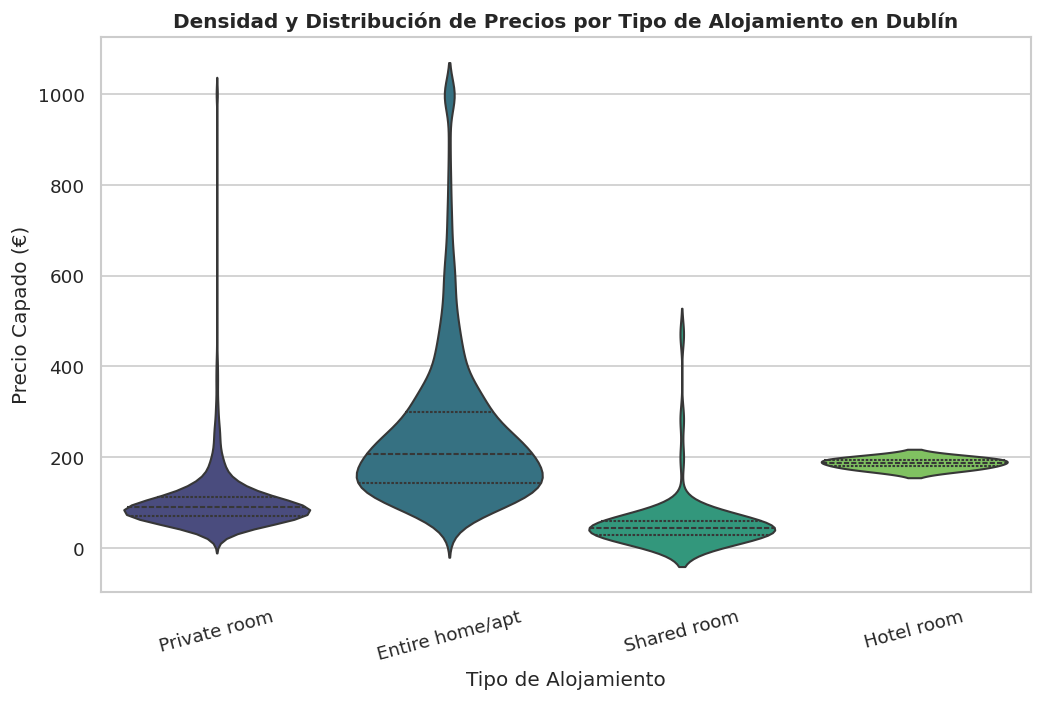

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.violinplot(data=df_clean, x='room_type', y='price_capped', palette='viridis', inner='quartile')
plt.title('Densidad y Distribución de Precios por Tipo de Alojamiento en Dublín', fontweight='bold')
plt.xlabel('Tipo de Alojamiento')
plt.ylabel('Precio Capado (€)')
plt.xticks(rotation=15)
plt.show()

---

# Justificación
La elección del Diagrama de Violín para este reto se justifica por su capacidad superior para revelar la estructura compleja del mercado de Airbnb en Dublín, superando las limitaciones de los gráficos univariados y de cajas vistos anteriormente. Dado que el dataset presenta un sesgo positivo extremo (26.85) y una dispersión donde la desviación estándar (€400.98) supera ampliamente a la media (€204.50), este gráfico resulta ideal porque añade una estimación de densidad de núcleo (KDE) al análisis

Esta característica permite visualizar no solo los cuartiles y la mediana, sino también la "forma" real de la oferta, mostrando con claridad en qué niveles de precio se "hincha" la distribución para cada tipo de alojamiento

Al utilizar la variable de precio capado al percentil 99 (€1,000.00), el violín logra exponer de manera orgánica cómo la mayoría de las unidades se concentran cerca de la mediana de €137.00, validando visualmente por qué esta es una medida más representativa que la media, la cual se ve arrastrada por la cola larga de los alojamientos de lujo

En definitiva, este análisis bivariado permite comparar simultáneamente la volatilidad de los precios en las casas completas (Entire home/apt), que dominan el 56.4% de la oferta, frente a la homogeneidad y bajo costo de las habitaciones compartidas, ofreciendo una perspectiva integral que el boxplot tradicional no logra capturar por sí solo


# ¿Qué se está analizando en él?
En este gráfico se analiza la segmentación del mercado de Airbnb en Dublín según el nivel de privacidad:

> Concentración de Precios: Se observa que tipos como "Shared room" tienen un "cuerpo" muy estrecho y bajo (mediana de €43), indicando una oferta muy homogénea y barata.

> Volatilidad y Lujo: El "violín" de "Entire home/apt" es mucho más alargado, lo que confirma visualmente la dispersión extrema mencionada en el diagnóstico del laboratorio (donde la desviación estándar general es de €400.98), demostrando que en este segmento conviven alojamientos estándar con otros de lujo que llegan al tope del capping de €1,000.

> Validación de la Mediana: El gráfico permite confirmar visualmente por qué la mediana es la medida más representativa: se ubica en la parte más ancha del violín para la mayoría de las categorías, a diferencia de la media que se ve arrastrada hacia el cuello superior del instrumento por los valores altos.

## Declaración de IA

¿Usé IA?
> Sí

¿Qué herramienta?
> NotebookLM

¿Para qué la usé?
> Utilicé la inteligencia artificial NotebookLM para verificar el diagnóstico estadístico y la interpretación de las distribuciones de precios. Ademas me ayudo a analizar el reto grafico para poder generar el diagrama de diagrama de violín, siendo que anterior a este ejercicio no había generado en programación de este tipo, indicandome que era el mejor grafico para capturar mejor la densidad del mercado frente a los valores extremos. Este AI en especifico es confiable por que utiliza unicamente los datos que uno provea como base para realizar las respuestas.

¿Qué aprendí de esa interacción?
>  De esta experiencia aprendí que la IA es un potente apoyo para transformar métricas abstractas en trabajos que requieren una analítica clara, siempre que se comprenda primero la naturaleza de las variables para guiar el análisis de forma rigurosa.


---

# Conclusión
> El uso de la AI en el desarrollo y analisis de los trabajos de programacion son bastante utiles para traer claridad del proceso, del por que se da y se genera de cierta manera a las personas que tenemos mayor dificultad de entender este idioma.

> Con relacion a los datos de Dublin se puede entender que los condados con mayor popularidad para la renta de un airbnb es en las zonas de Dublin City, South Dublin, Fingal y Laoghaire-Rathdown

---

# Referencias Bibliográficas
> Inside Airbnb. (2026). Dublin, Leinster, Ireland [Dataset]. Inside Airbnb. https://insideairbnb.com/dublin/